# 下一章：DQN 入门（PyTorch 版）

这一课还是上一章的内容，但这次我们不用纯手搓 `numpy` 网络，而是改成更接近真实项目写法的 `PyTorch` 版本。

这份 notebook 的目标是：
- 用 `PyTorch` 写出一个最小可运行的 DQN 风格 demo
- 保留最核心的 Q-learning 思想
- 在关键训练步骤旁边补上中文注释，帮助你真正看懂代码


## 1. 这一课和上一课的区别

上一课我们已经理解了 DQN 的核心思想：

- 不再使用 `Q 表`
- 改用神经网络来输出 `Q(s, a)`

这次的变化主要在实现层面：

- 网络用 `torch.nn.Module`
- 参数更新用 `optimizer.step()`
- 张量可以放到 `GPU` 上运行

不过要记住：

**算法的核心并没有变，变的只是实现工具。**


In [1]:
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [2]:
def pick_device():
    """
    优先尝试使用 GPU。
    但如果当前 PyTorch 版本和显卡架构不兼容，就自动回退到 CPU，避免 notebook 直接报错。
    """
    if torch.cuda.is_available():
        try:
            _ = torch.zeros(1, device='cuda')
            return torch.device('cuda')
        except Exception as e:
            warnings.warn(f'检测到 CUDA，但当前环境无法真正使用 GPU，已回退到 CPU。原因: {e}')
    return torch.device('cpu')


device = pick_device()
print('当前设备:', device)
if torch.cuda.is_available():
    print('检测到 CUDA 设备:', torch.cuda.get_device_name(0))


当前设备: cuda
检测到 CUDA 设备: NVIDIA GeForce RTX 5090


## 2. 环境还是最简单的一维走格子

这一课我们继续用最简单的一维环境，不让环境复杂度抢走注意力。

环境规则：
- 动作只有两个：`0=left`，`1=right`
- 每走一步有一个小惩罚 `-0.02`
- 到达终点时奖励为 `+1`

这样智能体就会倾向于更快到终点。


In [3]:
class LineWorld:
    def __init__(self, length=6):
        self.length = length
        self.goal = length - 1
        self.reset()

    def reset(self):
        self.position = 0
        return self.position

    def step(self, action):
        if action == 0:
            self.position = max(0, self.position - 1)
        else:
            self.position = min(self.goal, self.position + 1)

        reward = 1.0 if self.position == self.goal else -0.02
        done = self.position == self.goal
        return self.position, reward, done


## 3. 状态表示：把位置变成 one-hot 向量

我们的状态本来只是一个整数，比如 `0, 1, 2, 3, 4, 5`。

为了喂给神经网络，我们把它转换成 one-hot：

- 状态 0 -> `[1, 0, 0, 0, 0, 0]`
- 状态 3 -> `[0, 0, 0, 1, 0, 0]`

这样网络输入维度就是 `状态数`，输出维度就是 `动作数`。


In [4]:
def state_to_tensor(state, n_states, device):
    x = torch.zeros((1, n_states), dtype=torch.float32, device=device)
    x[0, state] = 1.0
    return x


## 4. 定义 Q 网络

这个网络很小：

- 输入：当前状态的 one-hot 向量
- 中间：一个隐藏层
- 输出：每个动作的 Q 值

比如输出 `[0.35, 0.72]`，就表示：
- 当前状态下，向左的 Q 值是 `0.35`
- 向右的 Q 值是 `0.72`


In [5]:
class QNetwork(nn.Module):
    def __init__(self, n_states, n_actions, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )

    def forward(self, x):
        return self.net(x)


## 5. 训练前先记住 DQN 的目标值

这一步是整节课最关键的地方。

目标值仍然来自 Q-learning：

$target = r + \gamma \max_{a'} Q(s', a')$

训练时我们会做 4 件事：

1. 让网络预测当前状态的所有动作 Q 值
2. 取出这次真正执行的那个动作的 Q 值
3. 用下一状态算出 TD target
4. 让当前预测往 target 靠近

这其实就是把“Q 表更新”变成了“神经网络拟合目标值”。


In [6]:
env = LineWorld(length=6)
n_states = env.length
n_actions = 2

q_net = QNetwork(n_states, n_actions, hidden_dim=32).to(device)
optimizer = optim.Adam(q_net.parameters(), lr=0.01)
criterion = nn.MSELoss()

gamma = 0.9
epsilon = 0.3
episodes = 300
max_steps = 40

episode_rewards = []
episode_steps = []
loss_history = []

for episode in range(episodes):
    state = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        state_tensor = state_to_tensor(state, n_states, device)

        # 前向计算：网络输出当前状态下两个动作的 Q 值
        q_values = q_net(state_tensor)

        # epsilon-greedy 选动作：
        # 有一部分概率随机探索，其余时候选当前 Q 值最大的动作
        if random.random() < epsilon:
            action = random.randint(0, n_actions - 1)
        else:
            action = int(torch.argmax(q_values, dim=1).item())

        next_state, reward, done = env.step(action)
        next_state_tensor = state_to_tensor(next_state, n_states, device)

        # 只在构造 target 时关闭梯度。
        # 因为 target 是“老师答案”，不需要反向传播回去。
        with torch.no_grad():
            next_q_values = q_net(next_state_tensor)
            max_next_q = torch.max(next_q_values, dim=1).values.item()
            target_value = reward if done else reward + gamma * max_next_q

        # 当前动作对应的预测值。
        # q_values 里有两个动作的 Q 值，但这一步只更新当前真正执行的那个动作。
        predicted_q = q_values[0, action]

        # 构造监督信号 target。
        # 这里把标量 target_value 包成张量，方便和 predicted_q 算 loss。
        target_q = torch.tensor(target_value, dtype=torch.float32, device=device)

        # loss 越小，说明当前预测越接近 TD target。
        loss = criterion(predicted_q, target_q)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(float(loss.item()))
        total_reward += reward
        state = next_state

        if done:
            episode_steps.append(step + 1)
            break
    else:
        episode_steps.append(max_steps)

    episode_rewards.append(total_reward)
    epsilon = max(0.02, epsilon * 0.995)

print('训练完成。')
print('最后 20 轮平均 reward:', round(float(np.mean(episode_rewards[-20:])), 3))


训练完成。
最后 20 轮平均 reward: 0.914


## 6. 看看网络到底学到了什么

虽然我们不再显式维护 `Q 表`，但依然可以把每个状态送进网络，看看它预测出来的 Q 值。

这样你会发现：
- 本质上还是在学每个状态下两个动作谁更好
- 只是这些数不再是查表得到，而是神经网络算出来的


In [7]:
q_net.eval()
predicted_q_table = []

print('各状态下网络预测的 Q 值：')
with torch.no_grad():
    for s in range(n_states):
        state_tensor = state_to_tensor(s, n_states, device)
        q = q_net(state_tensor).squeeze(0).detach().cpu().numpy()
        predicted_q_table.append(q)
        print(f'状态 {s}: left={q[0]:.3f}, right={q[1]:.3f}')

predicted_q_table = np.array(predicted_q_table)


各状态下网络预测的 Q 值：
状态 0: left=0.505, right=0.587
状态 1: left=0.535, right=0.666
状态 2: left=0.592, right=0.763
状态 3: left=0.674, right=0.880
状态 4: left=0.685, right=1.007
状态 5: left=0.477, right=0.541


In [8]:
action_map = {0: '←', 1: '→'}
policy = [action_map[int(np.argmax(predicted_q_table[s]))] for s in range(n_states - 1)] + ['G']

print('网络学到的策略：')
for s, a in enumerate(policy):
    print(f'状态 {s}: {a}')


网络学到的策略：
状态 0: →
状态 1: →
状态 2: →
状态 3: →
状态 4: →
状态 5: G


C:\Users\80740\AppData\Local\Temp\ipykernel_6088\360077882.py:18: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_6088\360077882.py:18: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_6088\360077882.py:18: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_6088\360077882.py:18: UserWarning: Glyph 22870 (\N{CJK UNIFIED IDEOGRAPH-5956}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_6088\360077882.py:18: UserWarning: Glyph 21169 (\N{CJK UNIFIED IDEOGRAPH-52B1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_6088\360077882.py:18: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing fro

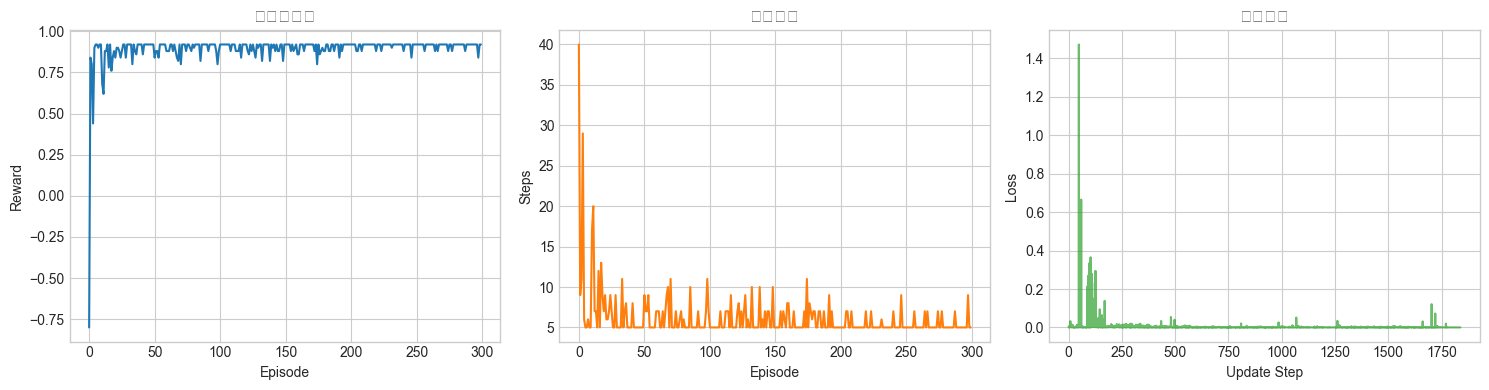

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(episode_rewards, color='#1f77b4')
axes[0].set_title('每轮总奖励')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')

axes[1].plot(episode_steps, color='#ff7f0e')
axes[1].set_title('每轮步数')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps')

axes[2].plot(loss_history, color='#2ca02c', alpha=0.7)
axes[2].set_title('训练损失')
axes[2].set_xlabel('Update Step')
axes[2].set_ylabel('Loss')

plt.tight_layout()
plt.show()


## 7. 这份 PyTorch 版要重点看哪几行

如果你想抓主线，最值得反复看的是训练循环里的这几步：

1. `q_values = q_net(state_tensor)`
   这是网络对当前状态的 Q 值预测。

2. `target_value = reward + gamma * max_next_q`
   这是 Q-learning 的 TD 目标。

3. `predicted_q = q_values[0, action]`
   这里只拿“当前执行动作”的预测值出来更新。

4. `loss.backward()` 和 `optimizer.step()`
   这两步负责真的更新网络参数。

这四步连起来，就是最小版 DQN 的骨架。


In [9]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

## 8. 下一课该学什么

这份 notebook 还是一个“最小可理解版本”。

真实 DQN 往往还会加两个关键结构：
- `Replay Buffer`
- `Target Network`

所以学完这一课，最自然的下一课就是：

**DQN 为什么要加经验回放和目标网络。**
